Cointegration p-value for KO/PEP (last 4 years): 0.0195

Sample log prices:
                  KO       PEP
Date                          
2021-11-18  3.977880  5.063171
2021-11-19  3.972811  5.065578
2021-11-22  3.978962  5.067620
2021-11-23  3.986331  5.074336
2021-11-24  3.978228  5.065155

Hedge ratio (KO/PEP): -0.3751

Sample spread and Z-score:
              KO_log   PEP_log    Spread    Zscore
Date                                              
2021-11-18  3.977880  5.063171  5.877232 -2.614256
2021-11-19  3.972811  5.065578  5.873067 -2.675964
2021-11-22  3.978962  5.067620  5.879983 -2.573505
2021-11-23  3.986331  5.074336  5.889871 -2.427028
2021-11-24  3.978228  5.065155  5.878325 -2.598071


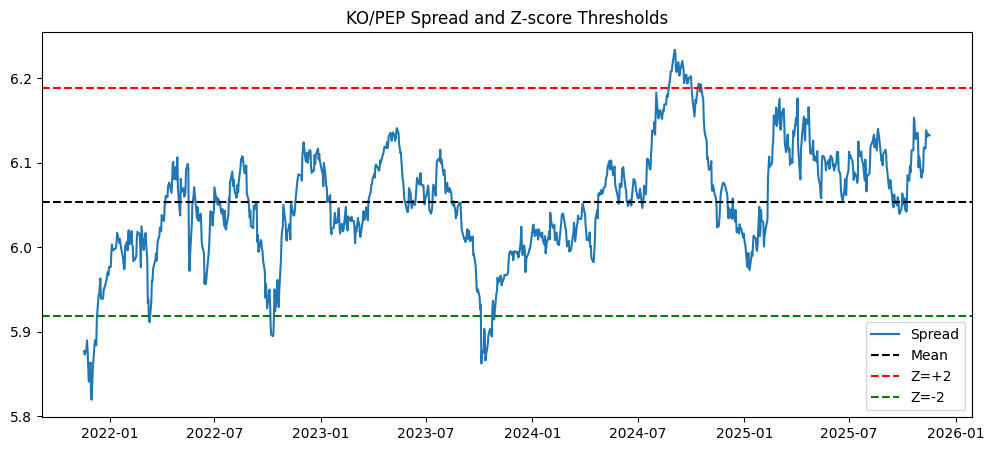

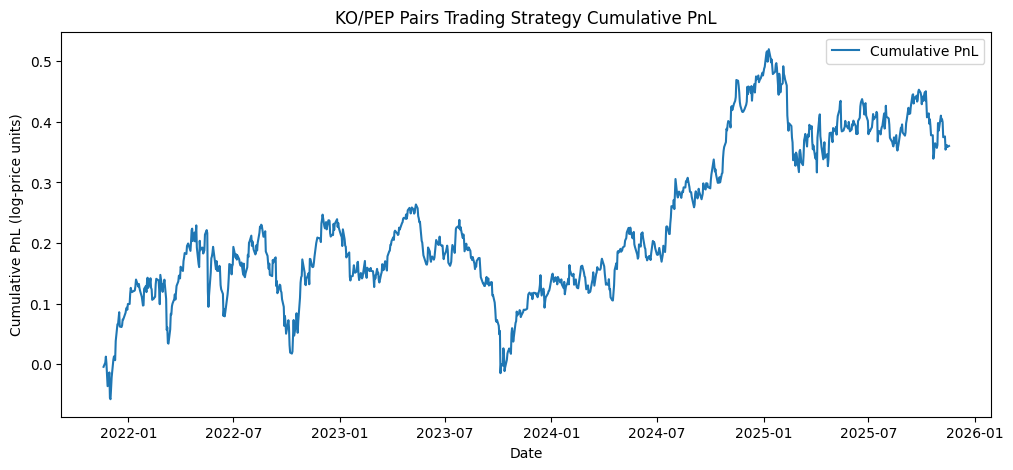


Sharpe ratio: 0.41
Number of trades: 1.0


In [26]:
# ===============================
# KO/PEP Pairs Trading Project
# ===============================

# Step 0: Install required package (run once)
# !pip install pandas-datareader statsmodels matplotlib

# Step 1: Import packages
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
from datetime import timedelta

# ===============================
# Step 2: Download Stooq data
# ===============================
s1 = "KO"
s2 = "PEP"
years = 4  # number of years to include

s1data = web.DataReader(s1 + ".US", "stooq").sort_index()
s2data = web.DataReader(s2 + ".US", "stooq").sort_index()

# ===============================
# Step 3: Trim to last `years` years
# ===============================
end_date = s1data.index[-1]
start_date = end_date - pd.Timedelta(days=365*years)

s1_trim = s1data.loc[s1data.index >= start_date]
s2_trim = s2data.loc[s2data.index >= start_date]

# ===============================
# Step 4: Compute log prices and align
# ===============================
s1_log = np.log(s1_trim['Close'])
s2_log = np.log(s2_trim['Close'])

s1_log.name = s1
s2_log.name = s2

s1_log, s2_log = s1_log.align(s2_log, join='inner')

# ===============================
# Step 5: Cointegration test
# ===============================
coint_t, p_value, _ = coint(s1_log, s2_log)
print(f"Cointegration p-value for {s1}/{s2} (last {years} years): {p_value:.4f}")

# Optional: inspect log prices
print("\nSample log prices:")
print(pd.concat([s1_log, s2_log], axis=1).head())

# ===============================
# Step 6: Hedge ratio & spread
# ===============================
X = sm.add_constant(s2_log)  # independent variable
y = s1_log                   # dependent variable

model = sm.OLS(y, X).fit()
hedge_ratio = model.params[s2]
print(f"\nHedge ratio ({s1}/{s2}): {hedge_ratio:.4f}")

# Construct spread
spread = y - hedge_ratio * s2_log

# ===============================
# Step 7: Compute Z-score
# ===============================
spread_mean = spread.mean()
spread_std = spread.std()
zscore = (spread - spread_mean) / spread_std

# Combine into DataFrame
signals = pd.DataFrame({
    f'{s1}_log': s1_log,
    f'{s2}_log': s2_log,
    'Spread': spread,
    'Zscore': zscore
})

print("\nSample spread and Z-score:")
print(signals.head())

# Plot spread and Z-score thresholds
plt.figure(figsize=(12,5))
plt.plot(spread, label='Spread')
plt.axhline(spread_mean, color='black', linestyle='--', label='Mean')
plt.axhline(spread_mean + 2*spread_std, color='red', linestyle='--', label='Z=+2')
plt.axhline(spread_mean - 2*spread_std, color='green', linestyle='--', label='Z=-2')
plt.title(f'{s1}/{s2} Spread and Z-score Thresholds')
plt.legend()
plt.show()

# ===============================
# Step 8: Generate trading signals
# ===============================
signals['long_entry']  = signals['Zscore'] < -2
signals['short_entry'] = signals['Zscore'] > 2
signals['exit']        = signals['Zscore'].abs() < 0.5

signals['position'] = 0
signals.loc[signals['long_entry'],  'position'] = 1
signals.loc[signals['short_entry'], 'position'] = -1
signals.loc[signals['exit'],        'position'] = 0

# Forward-fill positions until exit
signals['position'] = signals['position'].replace(0, np.nan).ffill().fillna(0)

# ===============================
# Step 9: Backtest PnL
# ===============================
spread_ret = signals['Spread'].diff()  # daily change in spread
signals['PnL'] = signals['position'] * spread_ret
signals['Cumulative_PnL'] = signals['PnL'].cumsum()

# Plot cumulative PnL
plt.figure(figsize=(12,5))
plt.plot(signals['Cumulative_PnL'], label='Cumulative PnL')
plt.title(f'{s1}/{s2} Pairs Trading Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL (log-price units)')
plt.legend()
plt.show()

# ===============================
# Step 10: Optional performance metrics
# ===============================
sharpe = signals['PnL'].mean() / signals['PnL'].std() * np.sqrt(252)
num_trades = signals['position'].diff().abs().sum() / 2  # each round-trip counts as one trade

print(f"\nSharpe ratio: {sharpe:.2f}")
print(f"Number of trades: {num_trades}")


In [27]:
  import os
  print(os.getcwd())

/Users/wonjunjo
